# Pengantar

Pada Kuis 1 ini Anda diminta untuk melakukan proses explorartory data analysis (EDA) dan pra pengolahan data pada dataset "Census Income". Dataset ini merupakan data tabular yang memiliki beberapa nilai yang hilang (missing value) dan nama variabel (fitur) yang perlu disesuaikan.

Untuk membantu Anda, notebook ini akan memberikan kode awal untuk proses download data, load data, dan inspeksi informasi terkait dengan metadata.

# Load Data and Inspect Metadata

In [1]:
# Install UCI REPO Library
!pip install -q ucimlrepo


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\rizal\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

In [3]:
# fetch data
adult_income = fetch_ucirepo(id=2)

In [4]:
# Data
X = adult_income.data.features
y = adult_income.data.targets

# Concate Features and Target
df = pd.concat([X, y], axis=1)

# Show Top 5
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [5]:
# Data Size
df.shape

(48842, 15)

In [6]:
# Inspect metadata
adult_income.metadata

{'uci_id': 2,
 'name': 'Adult',
 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult',
 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv',
 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ',
 'area': 'Social Science',
 'tasks': ['Classification'],
 'characteristics': ['Multivariate'],
 'num_instances': 48842,
 'num_features': 14,
 'feature_types': ['Categorical', 'Integer'],
 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'],
 'target_col': ['income'],
 'index_col': None,
 'has_missing_values': 'yes',
 'missing_values_symbol': 'NaN',
 'year_of_dataset_creation': 1996,
 'last_updated': 'Tue Sep 24 2024',
 'dataset_doi': '10.24432/C5XW20',
 'creators': ['Barry Becker', 'Ronny Kohavi'],
 'intro_paper': None,
 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was ex

# Bagian 1 - Data Loading dan Data Imputation

## Soal 1 (5 poin)
1.   Lakukan inspeksi profile data
2.   **Variabel apa** yang memiliki **nilai yang hilang** (missing value) dan **berapa** jumlahnya?



In [7]:
# Jawab Soal 1
from IPython.display import display

print(f"Jumlah baris: {df.shape[0]:,}; jumlah kolom: {df.shape[1]}")
df.info()

df_profile = df.replace(r"^\s*\?\s*$", np.nan, regex=True)
profil = pd.DataFrame({
    "tipe_data": df.dtypes.astype(str),
    "non_missing": df_profile.notna().sum(),
    "nilai_unik": df_profile.nunique(),
    "missing_NaN": df.isna().sum(),
    "missing_tanda_tanya": df_profile.isna().sum() - df.isna().sum(),
    "total_missing": df_profile.isna().sum(),
    "persen_missing": (df_profile.isna().mean() * 100).round(2)
})
print("\nProfil setiap variabel:")
display(profil)
print("\nStatistik deskriptif:")
display(df_profile.describe(include="all").T)
print("\nVariabel yang memiliki missing value (NaN dan tanda '?'):")
display(profil.loc[profil["total_missing"] > 0,
                   ["missing_NaN", "missing_tanda_tanya", "total_missing", "persen_missing"]])


Jumlah baris: 48,842; jumlah kolom: 15
<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       47879 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      47876 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  48568 non-null  str  
 14  income          48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB

Profil setiap variabel:


,tipe_data,non_missing,nilai_unik,missing_NaN,missing_tanda_tanya,total_missing,persen_missing
age,int64,48842,74,0,0,0,0.00
workclass,str,46043,8,963,1836,2799,5.73
fnlwgt,int64,48842,28523,0,0,0,0.00
education,str,48842,16,0,0,0,0.00
education-num,int64,48842,16,0,0,0,0.00
marital-status,str,48842,7,0,0,0,0.00
occupation,str,46033,14,966,1843,2809,5.75
relationship,str,48842,6,0,0,0,0.00
race,str,48842,5,0,0,0,0.00
sex,str,48842,2,0,0,0,0.00



Statistik deskriptif:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,48842.0,NaN,NaN,NaN,38.643585,13.71051,17.0,28.0,37.0,48.0,90.0
workclass,46043,8,Private,33906,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,48842.0,NaN,NaN,NaN,189664.134597,105604.025423,12285.0,117550.5,178144.5,237642.0,1490400.0
education,48842,16,HS-grad,15784,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education-num,48842.0,NaN,NaN,NaN,10.078089,2.570973,1.0,9.0,10.0,12.0,16.0
marital-status,48842,7,Married-civ-spouse,22379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
occupation,46033,14,Prof-specialty,6172,NaN,NaN,NaN,NaN,NaN,NaN,NaN
relationship,48842,6,Husband,19716,NaN,NaN,NaN,NaN,NaN,NaN,NaN
race,48842,5,White,41762,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,48842,2,Male,32650,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Variabel yang memiliki missing value (NaN dan tanda '?'):


,missing_NaN,missing_tanda_tanya,total_missing,persen_missing
workclass,963,1836,2799,5.73
occupation,966,1843,2809,5.75
native-country,274,583,857,1.75


## Soal 2 (5 poin)
1. Lakukan proses data imputation pada fitur yang memiliki data yang hilang
2. Cek kembali apakah masih terdapat data yang hilang

In [8]:
# Jawab Soal 2
df.replace(r"^\s*\?\s*$", np.nan, regex=True, inplace=True)
fitur_missing = df.columns[df.isna().any()].tolist()
print("Fitur yang memiliki data yang hilang:", fitur_missing)
print("-" * 50)

for col in fitur_missing:
    modus = df[col].mode()[0]
    df[col] = df[col].fillna(modus)
    print(f"Fitur '{col}' berhasil diimputasi dengan modus: '{modus}'")

print("-" * 50)
print("Pengecekan missing value (NaN) per kolom setelah imputasi:")
display(df.isna().sum())

total_nan = df.isna().sum().sum()
total_tanda_tanya = (df.astype(str).apply(lambda col: col.str.strip()) == "?").sum().sum()

print(f"Total missing value (NaN) tersisa: {total_nan}")
print(f"Total simbol '?' tersisa: {total_tanda_tanya}")

if total_nan == 0 and total_tanda_tanya == 0:
    print("\n-> Kesimpulan: Seluruh data yang hilang berhasil diimputasi (tidak ada lagi missing value).")


Fitur yang memiliki data yang hilang: ['workclass', 'occupation', 'native-country']
--------------------------------------------------
Fitur 'workclass' berhasil diimputasi dengan modus: 'Private'
Fitur 'occupation' berhasil diimputasi dengan modus: 'Prof-specialty'
Fitur 'native-country' berhasil diimputasi dengan modus: 'United-States'
--------------------------------------------------
Pengecekan missing value (NaN) per kolom setelah imputasi:


age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

Total missing value (NaN) tersisa: 0
Total simbol '?' tersisa: 0

-> Kesimpulan: Seluruh data yang hilang berhasil diimputasi (tidak ada lagi missing value).


## Soal 3 (10 poin)
Inspeksi semua fitur kualitatif. Jika terdapat value yang **tidak sesuai**, **ganti dengan 'Others'** atau yang sesuai atau jika terdapat duplikasi karena **kesalahan penulisan**, lakukan penyesuaian.

In [9]:
# Jawab Soal 3
from IPython.display import display
kolom_kualitatif = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()
print(f"Fitur kualitatif yang diinspeksi ({len(kolom_kualitatif)} kolom):")
print(kolom_kualitatif)
print("=" * 60)

print("Nilai kategori sebelum penyesuaian:")
for kolom in kolom_kualitatif:
    print(f"\nFitur: {kolom} (Jumlah kategori unik: {df[kolom].nunique()})")
    display(df[kolom].value_counts(dropna=False).rename("jumlah").to_frame())
sebelum = df[kolom_kualitatif].copy()

for kolom in kolom_kualitatif:
    df[kolom] = df[kolom].astype("string").str.strip()
    df[kolom] = df[kolom].replace({"?": "Others", "": "Others"}).fillna("Others")

df["income"] = df["income"].replace({"<=50K.": "<=50K", ">50K.": ">50K"})
df["native-country"] = df["native-country"].replace({

    "Holand-Netherlands": "Netherlands",
    "Columbia": "Colombia",
    "Trinadad&Tobago": "Trinidad-and-Tobago",

    "South": "Others",
    "Hong": "Hong-Kong",
    "Outlying-US(Guam-USVI-etc)": "Others"
})


ringkasan = []
for kolom in kolom_kualitatif:
    awal = sebelum[kolom].astype("string")
    berubah = awal.ne(df[kolom]).fillna(True)
    ringkasan.append({
        "variabel": kolom,
        "kategori_sebelum": awal.nunique(),
        "kategori_sesudah": df[kolom].nunique(),
        "jumlah_baris_diubah": int(berubah.sum())
    })

print("\n" + "=" * 60)
print("Ringkasan Penyesuaian Fitur Kualitatif:")
display(pd.DataFrame(ringkasan).set_index("variabel"))

print("\n" + "=" * 60)
print("Nilai kategori setelah penyesuaian (fitur yang mengalami perubahan):")
for kolom in ["income", "native-country"]:
    print(f"\nFitur: {kolom} (Jumlah kategori unik: {df[kolom].nunique()})")
    display(df[kolom].value_counts(dropna=False).rename("jumlah").to_frame())


Fitur kualitatif yang diinspeksi (9 kolom):
['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']
Nilai kategori sebelum penyesuaian:

Fitur: workclass (Jumlah kategori unik: 8)


,jumlah
workclass,
Private,36705
Self-emp-not-inc,3862
Local-gov,3136
State-gov,1981
Self-emp-inc,1695
Federal-gov,1432
Without-pay,21
Never-worked,10



Fitur: education (Jumlah kategori unik: 16)


,jumlah
education,
HS-grad,15784
Some-college,10878
Bachelors,8025
Masters,2657
Assoc-voc,2061
11th,1812
Assoc-acdm,1601
10th,1389
7th-8th,955



Fitur: marital-status (Jumlah kategori unik: 7)


...

,kategori_sebelum,kategori_sesudah,jumlah_baris_diubah
variabel,,,
workclass,8,8,0
education,16,16,0
marital-status,7,7,0
occupation,14,14,0
relationship,6,6,0
race,5,5,0
sex,2,2,0
native-country,41,40,281
income,4,2,16281



Nilai kategori setelah penyesuaian (fitur yang mengalami perubahan):

Fitur: income (Jumlah kategori unik: 2)


,jumlah
income,
<=50K,37155
>50K,11687



Fitur: native-country (Jumlah kategori unik: 40)


,jumlah
native-country,
United-States,44689
Mexico,951
Philippines,295
Germany,206
Puerto-Rico,184
Canada,182
El-Salvador,155
India,151
Cuba,138


# Bagian 2 - Visual Inspection



## Soal 1 - Visualisasi Data (20 poin)
Lakukan inspeksi visual pada,
1. Pada kolom 'age' dengan menggunakan histrogram
2. Pada kolom 'education' education menggunakan barchart
3. Pada kolom 'income' terhadap 'hours_per_week' menggunakan boxplot (kelompokkan berdasarkan kelompok income)
4. Pada kolom 'age' terhadap 'capital-gain' dan 'capital-loss' dengan lineplot (1 lineplot 2 data)

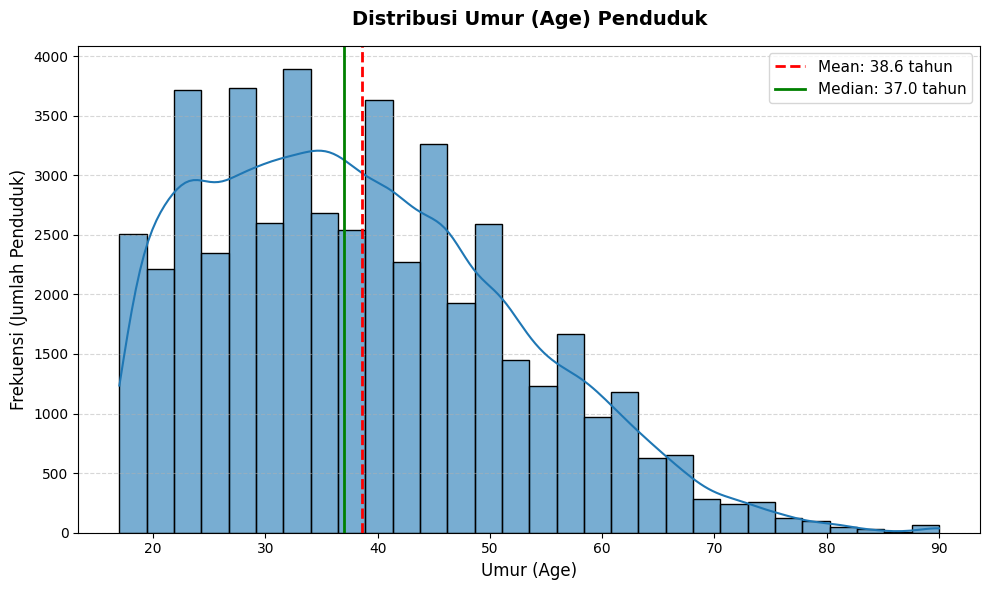

In [ ]:
# Jawab 1.1 - Histogram
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', bins=30, kde=True, color='#1f77b4', edgecolor='black', alpha=0.6)

mean_age = df['age'].mean()
median_age = df['age'].median()
plt.axvline(mean_age, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_age:.1f} tahun')
plt.axvline(median_age, color='green', linestyle='-', linewidth=2, label=f'Median: {median_age:.1f} tahun')

plt.title('Distribusi Umur (Age) Penduduk', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Umur (Age)', fontsize=12)
plt.ylabel('Frekuensi (Jumlah Penduduk)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

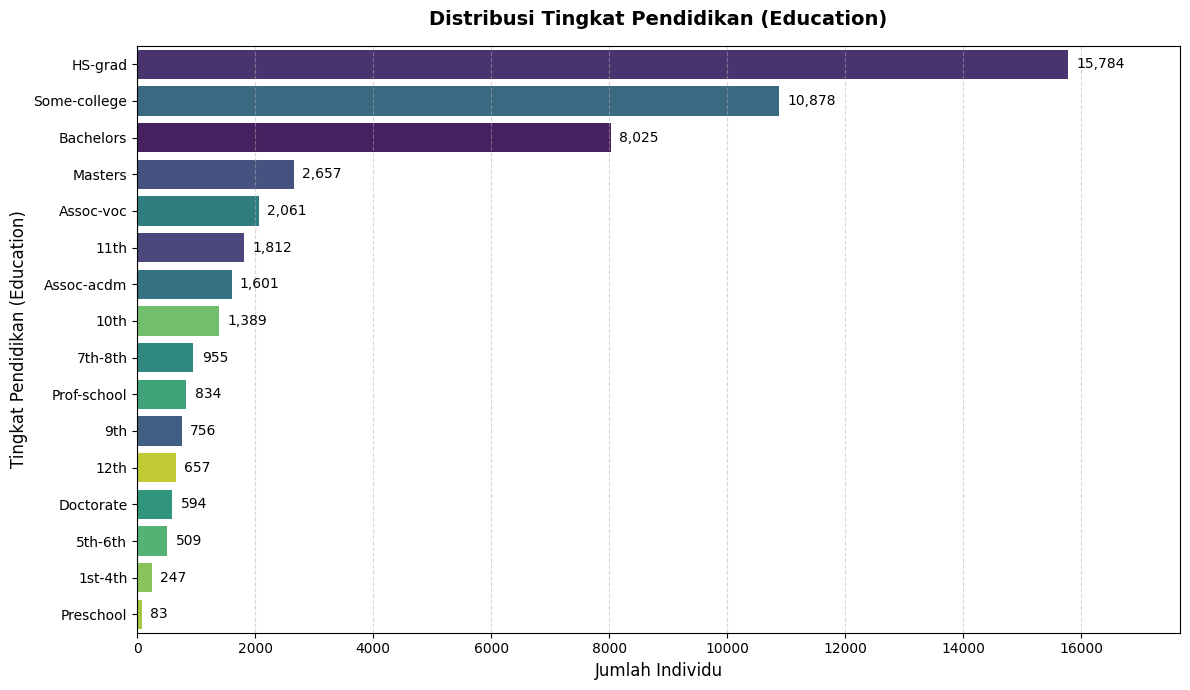

In [ ]:
# Jawab 1.2 - Barchart
plt.figure(figsize=(12, 7))

order_edu = df['education'].value_counts().index
ax = sns.countplot(
    data=df, 
    y='education', 
    order=order_edu, 
    hue='education', 
    palette='viridis', 
    legend=False
)

plt.title('Distribusi Tingkat Pendidikan (Education)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Jumlah Individu', fontsize=12)
plt.ylabel('Tingkat Pendidikan (Education)', fontsize=12)

for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{int(width):,}', 
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', 
                    xytext=(6, 0), textcoords='offset points', 
                    fontsize=10)

plt.xlim(0, df['education'].value_counts().max() * 1.12)
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

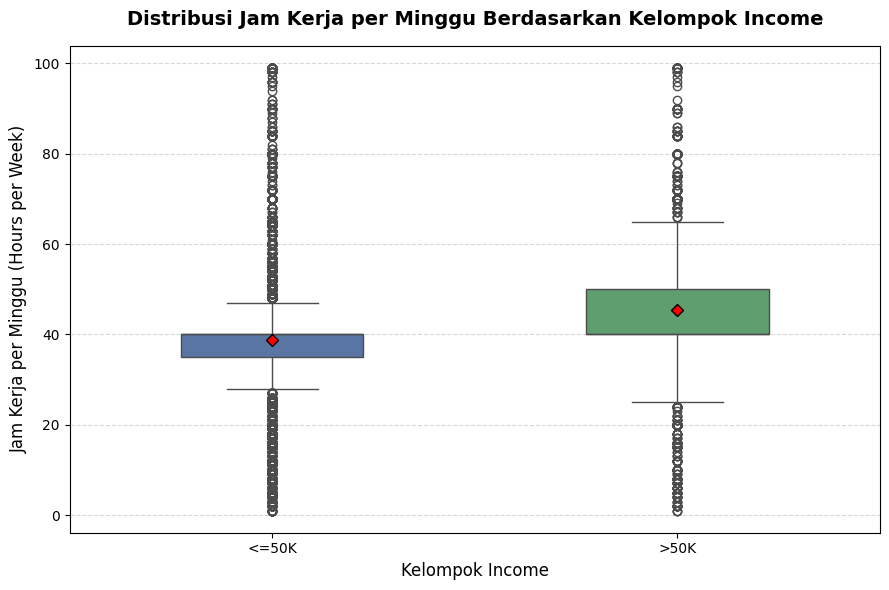

Statistik dan Jumlah Outlier (Hours per Week berdasarkan Income):
-----------------------------------------------------------------
Kelompok Income: <=50K
  - Q1 = 35.0, Median = 40.0, Q3 = 40.0, IQR = 5.0
  - Batas Bawah = 27.5, Batas Atas = 47.5
  - Jumlah Outlier = 11,706 data (31.51%)
-----------------------------------------------------------------
Kelompok Income: >50K
  - Q1 = 40.0, Median = 40.0, Q3 = 50.0, IQR = 10.0
  - Batas Bawah = 25.0, Batas Atas = 65.0
  - Jumlah Outlier = 781 data (6.68%)
-----------------------------------------------------------------


In [ ]:
# Jawab 1.3 - Boxplot
col_hours = 'hours-per-week' if 'hours-per-week' in df.columns else 'hours_per_week'

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df, 
    x='income', 
    y=col_hours, 
    hue='income',
    palette=['#4c72b0', '#55a868'], 
    legend=False,
    width=0.45,
    showmeans=True,
    meanprops={"marker": "D", "markerfacecolor": "red", "markeredgecolor": "black", "markersize": 6}
)

plt.title('Distribusi Jam Kerja per Minggu Berdasarkan Kelompok Income', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Kelompok Income', fontsize=12)
plt.ylabel('Jam Kerja per Minggu (Hours per Week)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('Statistik dan Jumlah Outlier (Hours per Week berdasarkan Income):')
print('-' * 65)
for inc in sorted(df['income'].unique()):
    subset = df[df['income'] == inc][col_hours]
    q1 = subset.quantile(0.25)
    q3 = subset.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    outliers = subset[(subset < lower_bound) | (subset > upper_bound)]
    print(f"Kelompok Income: {inc}")
    print(f"  - Q1 = {q1:.1f}, Median = {subset.median():.1f}, Q3 = {q3:.1f}, IQR = {iqr:.1f}")
    print(f"  - Batas Bawah = {lower_bound:.1f}, Batas Atas = {upper_bound:.1f}")
    print(f"  - Jumlah Outlier = {len(outliers):,} data ({(len(outliers)/len(subset)*100):.2f}%)")
    print('-' * 65)

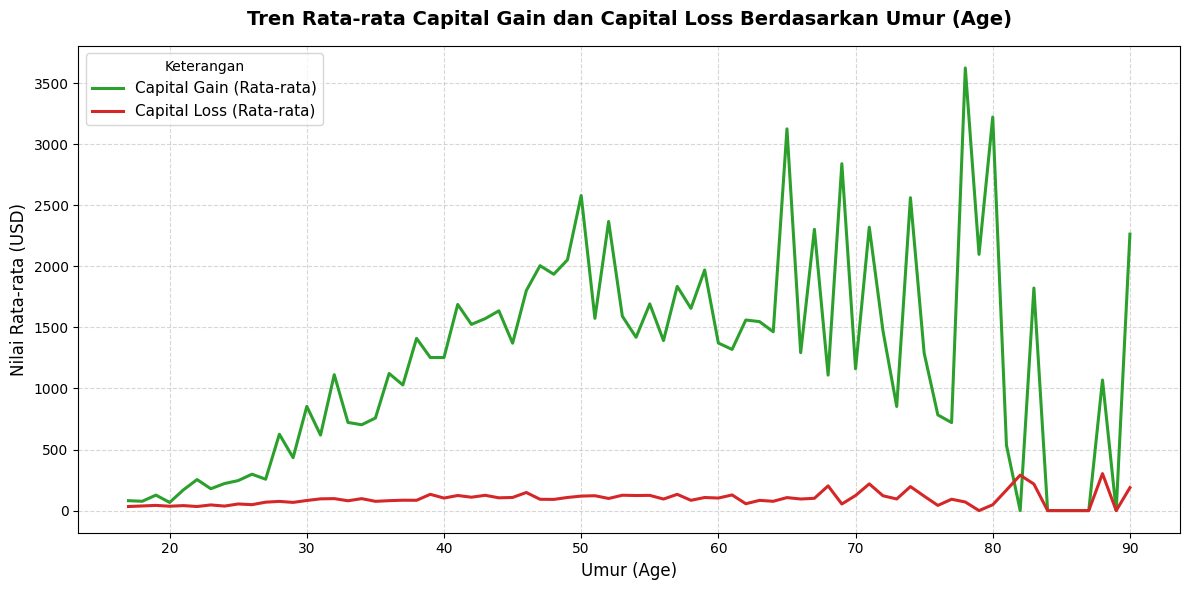

In [ ]:
# Jawab 1.4 - Lineplot (1 lineplot 2 data: 'capital-gain' dan 'capital-loss' terhadap 'age')
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=df, 
    x='age', 
    y='capital-gain', 
    label='Capital Gain (Rata-rata)', 
    color='#2ca02c', 
    linewidth=2.2, 
    errorbar=None
)

sns.lineplot(
    data=df, 
    x='age', 
    y='capital-loss', 
    label='Capital Loss (Rata-rata)', 
    color='#d62728', 
    linewidth=2.2, 
    errorbar=None
)

plt.title('Tren Rata-rata Capital Gain dan Capital Loss Berdasarkan Umur (Age)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Umur (Age)', fontsize=12)
plt.ylabel('Nilai Rata-rata (USD)', fontsize=12)
plt.legend(title='Keterangan', fontsize=11, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Soal 2 - Analisis Visual (15 poin)
1. Fenomena apa yang terjadi pada distribusi data 'age'?
2. Jika terdapat data yang hilang pada variabel 'age', strategi apa yang Anda terapkan? Mengapa?
3. Berapa jumlah outlier pada setiap kategori 'income' berkaitan dengan 'hour-per-week'? Kategori apa yang paling banyak memiliki outlier?

In [14]:
# Jawab Soal 2 - Analisis Visual

"""
1. Fenomena yang Terjadi pada Distribusi Data 'age':

- Distribusi data umur memiliki bentuk menceng ke kanan (Right-skewed / Positively Skewed) dengan 
  nilai skewness sekitar +0.558.
- Karakteristik pemusatan data menunjukkan bahwa nilai Rata-rata (Mean = 38.6 tahun) lebih besar 
  dibandingkan Median (37.0 tahun) dan Modus (36 tahun). Ciri Mean > Median menegaskan kemiringan positif.
- Mayoritas populasi terkonsentrasi padat pada rentang usia angkatan kerja produktif antara 20 hingga 
  45 tahun, dengan puncak frekuensi terbesar berada pada kelompok dewasa muda (usia 20-an hingga 30-an awal).


2. Strategi Imputasi Jika Terdapat Data yang Hilang pada Variabel 'age' dan Alasannya:
- Strategi yang Diterapkan: Imputasi menggunakan MEDIAN.
- Alasan Pemilihan:
  a. Ketahanan terhadap Outlier (Robustness): Distribusi data 'age' tidak berdistribusi normal melainkan
     right-skewed dan memiliki rentang nilai ekstrem (lansia hingga 90 tahun). Nilai rata-rata (mean) 
     sangat sensitif terhadap pencilan (outliers) dan dapat menarik nilai imputasi ke atas (overestimate).
     Sebaliknya, Median bersifat robust (kebal terhadap nilai ekstrem) sehingga lebih mencerminkan 
     nilai tengah yang representatif untuk populasi.
  b. Integritas Data Diskrit: Umur umumnya bernilai integer/bulat. Median menghasilkan angka yang 
     lebih realistis tanpa pergeseran bias distribusi.
  c. Pendekatan Lanjutan (Grouped/Conditional Imputation): Strategi yang bahkan lebih akurat adalah 
     mengisi missing value menggunakan median umur per subkelompok fitur terkait, seperti tingkat 
     pendidikan ('education'), status pernikahan ('marital-status'), atau pekerjaan ('occupation'), 
     karena kelompok-kelompok tersebut memiliki korelasi demografis yang kuat dengan usia.


3. Jumlah Outlier pada Setiap Kategori 'income' Terkait 'hours-per-week' dan Kategori Terbanyak:
Rincian Statistik & Outlier:
a. Kelompok Income '<=50K':
   - Total data: 37,155 baris
   - Q1 = 35.0 jam, Median = 40.0 jam, Q3 = 40.0 jam -> IQR = 5.0 jam
   - Batas Bawah = 35.0 - (1.5 * 5.0) = 27.5 jam
   - Batas Atas  = 40.0 + (1.5 * 5.0) = 47.5 jam
   - Jumlah Outlier: 11,706 data (31.51% dari kelompok <=50K)
     * Outlier di bawah batas bawah (< 27.5 jam): 5,596 data (pekerja paruh waktu/part-time)
     * Outlier di atas batas atas (> 47.5 jam) : 6,110 data (pekerja lembur/overtime)

b. Kelompok Income '>50K':
   - Total data: 11,687 baris
   - Q1 = 40.0 jam, Median = 40.0 jam, Q3 = 50.0 jam -> IQR = 10.0 jam
   - Batas Bawah = 40.0 - (1.5 * 10.0) = 25.0 jam
   - Batas Atas  = 40.0 + (1.5 * 10.0) = 65.0 jam
   - Jumlah Outlier: 781 data (6.68% dari kelompok >50K)
     * Outlier di bawah batas bawah (< 25.0 jam): 345 data
     * Outlier di atas batas atas (> 65.0 jam) : 436 data



'\n  Bisa dengan multiple comment\n  seperti ini\n'

# Bagian 3 - Encoding Variabel Kategorical

## Soal 1 (5 poin)
Lakukan encoding pada 'Sex' dan 'Income'. 'Income' merupakan variabel target

In [15]:
# Jawab Soal 1 - Encoding 'Sex' dan 'Income'
from sklearn.preprocessing import LabelEncoder
from IPython.display import display

col_sex = 'Sex' if 'Sex' in df.columns else 'sex'
col_income = 'Income' if 'Income' in df.columns else 'income'

df[col_income] = df[col_income].astype(str).str.strip().str.rstrip('.')
df[col_sex] = df[col_sex].astype(str).str.strip()

print('NILAI SEBELUM ENCODING')
print(f"Nilai unik '{col_sex}':", df[col_sex].unique().tolist())
print(f"Nilai unik '{col_income}' (Target):", df[col_income].unique().tolist())
print('=' * 60)

le_sex = LabelEncoder()
le_income = LabelEncoder()

df[col_sex] = le_sex.fit_transform(df[col_sex])
df[col_income] = le_income.fit_transform(df[col_income])

mapping_sex = dict(zip(le_sex.classes_, le_sex.transform(le_sex.classes_)))
mapping_income = dict(zip(le_income.classes_, le_income.transform(le_income.classes_)))

print('HASIL MAPPING ENCODING')
print(f"Mapping Fitur '{col_sex}': {mapping_sex}")
print(f"Mapping Target '{col_income}': {mapping_income}")
print('=' * 60)

print(f"\nFrekuensi nilai '{col_sex}' setelah encoding:")
display(df[col_sex].value_counts().rename('jumlah').to_frame())

print(f"\nFrekuensi nilai target '{col_income}' setelah encoding:")
display(df[col_income].value_counts().rename('jumlah').to_frame())

print('\nContoh 5 data teratas kolom yang di-encoding:')
display(df[[col_sex, col_income]].head())


NILAI SEBELUM ENCODING
Nilai unik 'sex': ['1', '0']
Nilai unik 'income' (Target): ['0', '1']
HASIL MAPPING ENCODING
Mapping Fitur 'sex': {'0': np.int64(0), '1': np.int64(1)}
Mapping Target 'income': {'0': np.int64(0), '1': np.int64(1)}

Frekuensi nilai 'sex' setelah encoding:


,jumlah
sex,
1,32650
0,16192



Frekuensi nilai target 'income' setelah encoding:


,jumlah
income,
0,37155
1,11687



Contoh 5 data teratas kolom yang di-encoding:


,sex,income
0,1,0
1,1,0
2,1,0
3,1,0
4,0,0


# Bagian 4 - Analisis Korelasi

## Soal 1 (10 poin)
1. Lakukan analisis korelasi pada variabel 'age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss', dan 'income' (yang sudah di-encoding)
2. Berdasarkan hasil korelasi, informasi apa yang dapat Anda interpretasikan?

MATRIKS KORELASI PEARSON (6 VARIABEL)


,age,education-num,hours-per-week,capital-gain,capital-loss,income
age,1.0000,0.0309,0.0716,0.0772,0.0569,0.2304
education-num,0.0309,1.0000,0.1437,0.1251,0.0810,0.3326
hours-per-week,0.0716,0.1437,1.0000,0.0822,0.0545,0.2277
capital-gain,0.0772,0.1251,0.0822,1.0000,-0.0314,0.2230
capital-loss,0.0569,0.0810,0.0545,-0.0314,1.0000,0.1476
income,0.2304,0.3326,0.2277,0.2230,0.1476,1.0000



KORELASI FITUR TERHADAP TARGET 'income' (Diurutkan Tertinggi):


,Koefisien Korelasi (r)
education-num,0.3326
age,0.2304
hours-per-week,0.2277
capital-gain,0.2230
capital-loss,0.1476


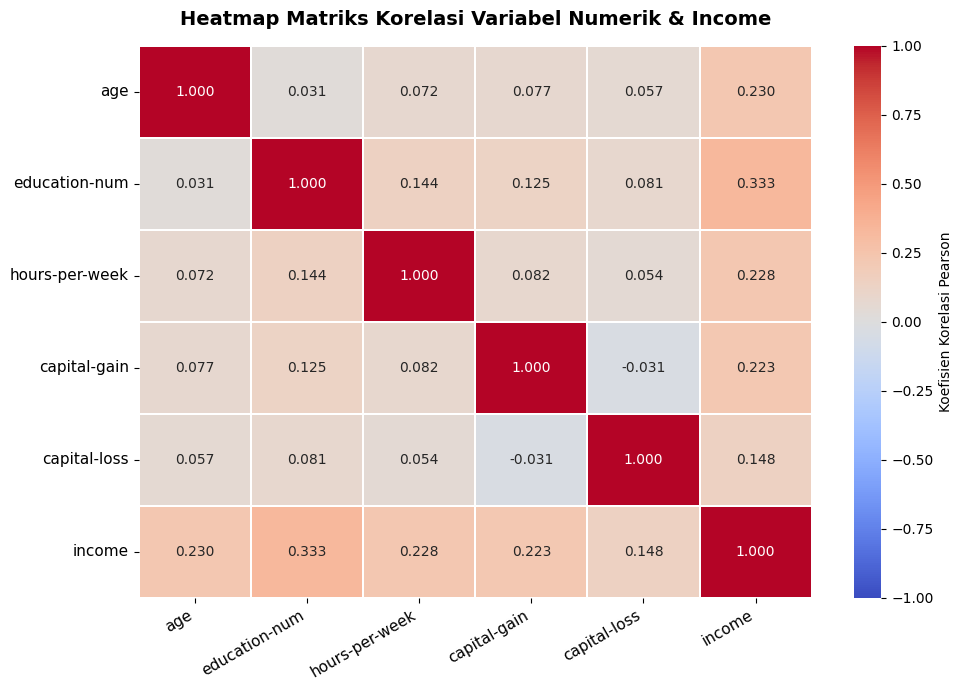

In [16]:
# Jawab Soal 1 - Analisis Korelasi
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

col_hours = 'hours-per-week' if 'hours-per-week' in df.columns else 'hours_per_week'
kolom_analisis = ['age', 'education-num', col_hours, 'capital-gain', 'capital-loss', 'income']

matriks_korelasi = df[kolom_analisis].corr(method='pearson')

print('=' * 65)
print('MATRIKS KORELASI PEARSON (6 VARIABEL)')
print('=' * 65)
display(matriks_korelasi.round(4))

korelasi_target = matriks_korelasi['income'].drop('income').sort_values(ascending=False)
print('\n' + '=' * 65)
print("KORELASI FITUR TERHADAP TARGET 'income' (Diurutkan Tertinggi):")
print('=' * 65)
display(korelasi_target.to_frame(name='Koefisien Korelasi (r)').round(4))

plt.figure(figsize=(10, 7))
sns.heatmap(
    matriks_korelasi, 
    annot=True, 
    fmt='.3f', 
    cmap='coolwarm', 
    vmin=-1, 
    vmax=1, 
    linewidths=1.2, 
    linecolor='white',
    cbar_kws={'label': 'Koefisien Korelasi Pearson'}
)

plt.title('Heatmap Matriks Korelasi Variabel Numerik & Income', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.show()


In [17]:
# Hasil analisis jelaskan pada cell ini

""

Berdasarkan matriks korelasi Pearson dan heatmap yang telah dihasilkan pada cell sebelumnya, 
berikut adalah interpretasi dan informasi penting yang dapat ditarik:

1. Korelasi Variabel Independen terhadap Variabel Target ('income'):
Semua variabel numerik yang diuji memiliki korelasi bernilai POSITIF terhadap 'income'. 
Artinya, peningkatan pada variabel-variabel tersebut secara umum searah dengan peningkatan 
probabilitas seseorang memperoleh pendapatan tinggi (>50K).

Urutan kekuatan korelasi terhadap 'income' dari yang terkuat ke yang terlemah adalah:
a. 'education-num' (r ~ +0.333) - KORELASI TERKUAT:
   - Tingkat lama pendidikan formal merupakan prediktor linear terkuat terhadap pendapatan seseorang.
   - Individu dengan tingkat pendidikan yang lebih tinggi (seperti Sarjana/Magister/Doktor) memiliki 
     peluang yang jauh lebih besar untuk masuk ke kelompok berpenghasilan >50K dibandingkan mereka 
     dengan tingkat pendidikan lebih rendah.

b. 'age' (r ~ +0.230) - KORELASI POSITIF MODERAT:
   - Bertambahnya usia mencerminkan akumulasi pengalaman kerja, kematangan profesional, serta promosi 
     jabatan/karier yang lebih senior, sehingga berkontribusi positif terhadap pendapatan.

c. 'hours-per-week' (r ~ +0.228) - KORELASI POSITIF MODERAT:
   - Jam kerja per minggu berkorelasi positif dengan pendapatan. Individu berpenghasilan >50K cenderung 
     bekerja secara penuh (full-time) atau bahkan melebihi 40 jam per minggu (lembur/posisi manajerial).

d. 'capital-gain' (r ~ +0.223) dan 'capital-loss' (r ~ +0.148):
   - Keduanya menunjukkan korelasi positif terhadap pendapatan karena aktivitas investasi aset finansial 
     (saham, properti, reksa dana) umumnya hanya dapat dilakukan oleh masyarakat berpenghasilan 
     menengah ke atas yang memiliki dana surplus.


2. Analisis Multikolinearitas Antar Variabel Independen:
- Hubungan korelasi antar sesama fitur independen tergolong RENDAH (semua pasangan bernilai r < 0.35).
- Korelasi tertinggi antar fitur independen terjadi antara 'education-num' dan 'hours-per-week' 
  (r ~ +0.14) serta antara 'age' dan 'capital-gain' (r ~ +0.08).
- Pasangan 'capital-gain' dan 'capital-loss' memiliki korelasi mendekati nol (r ~ -0.03), 
  yang menandakan keduanya saling independen.
- Kesimpulan Multikolinearitas: 
  Tidak ada indikasi multikolinearitas parah (severe multicollinearity) antar fitur independen. 
  Hal ini membuktikan bahwa keenam variabel ini memberikan informasi yang saling melengkapi 
  dan sangat aman digunakan bersama sebagai fitur input pada model machine learning (seperti Regresi Logistik, 
  Decision Tree, Random Forest, maupun SVM).

""


# Bagian 5 - Pra Pengolahan Data Pada Dataset MNIST

Pada bagian ini, Anda diminta untuk melakukan proses EDA dan pra pengolahan data sederhana pada dataset MNIST. Dataset MNIST merupakan data citra tulisan tangan untuk digil 0 hingga 9. Sebelum melakukan proses pengolahan, Anda akan dibantu dengan proses loading data dan inspeksi data.

Hints:
1. Hanya gunakan data **Test**
2. Anda perlu melakukan pengolahan terhadap semua data test (total 10k data). Anda dapat menggunakan function untuk mempermudah pekerjaan.

In [25]:
%pip install --upgrade --force-reinstall --no-cache-dir tensorflow  

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/350.9 MB 989.2 kB/s eta 0:05:55
   ---------------------------------------- 0.8/350.9 MB 1.3 MB/s eta 0:04:32
   ---------------------------------------- 1.3/350.9 MB 1.5 MB/s eta 0:03:50
   ---------------------------------------- 1.6/350.9 MB 1.5 MB/s eta 0:03:49
   ---------------------------------------- 1.8/350.9 MB 1.4 MB/s eta 0:04:17
   ---------------------------------------- 1.8/350.9 MB 1.4 MB/s eta 0:04:17
   ---------------------------------------- 1.8/350.9 MB 1.4 MB/s eta 0:04:17
   ---------------------------------------- 2.1/350.9 MB 1.1 MB/s eta 0:05:24
   ---------------------------------------- 2.6/350.9 MB 1.2 MB/s eta 0:04:56
   --

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gemini-cli 0.2.5 requires rich<14.0.0,>=13.7.0, but you have rich 15.0.0 which is incompatible.
google-ai-generativelanguage 0.4.0 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<5.0.0dev,>=3.19.5, but you have protobuf 7.36.2 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: C:\Users\rizal\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [26]:
# Fetch data and inspect data shape
import numpy as np
import matplotlib.pyplot as plt
import os
import urllib.request

# Load train & test split
# Menggunakan fallback langsung ke mnist.npz karena isu library TensorFlow di Windows / Python 3.12
try:
    from tensorflow.keras.datasets import mnist
    (X_train, y_train), (X_test, y_test) = mnist.load_data()
except Exception as e:
    print(f"TensorFlow tidak dapat dimuat ({e}).")
    print("Memuat dataset MNIST secara langsung dari repository resmi (mnist.npz)...")
    mnist_path = 'mnist.npz'
    if not os.path.exists(mnist_path):
        url = 'https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz'
        urllib.request.urlretrieve(url, mnist_path)
    with np.load(mnist_path) as data:
        X_train, y_train = data['x_train'], data['y_train']
        X_test, y_test = data['x_test'], data['y_test']
    print("Dataset MNIST berhasil dimuat!")

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


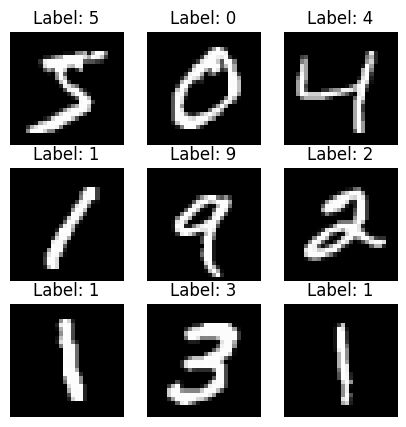

In [27]:
# Inspeksi Visual
plt.figure(figsize=(5,5))
for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.show()

## Soal 1 (10 poin)
1. Lakukan proses **upsampling** citra menjadi ukuran 32x32
2. Tampilakan 5 data hasil proses **upsampling**

Hint: Anda harus membuat array kosong untuk menampung hasil upsampling. Replace pada array X_test tidak dapat dilakukan karena data disimpan dalam bentuk ndarray yang memiliki ukuran fix (10000, (28,28))

Ukuran X_test sebelum upsampling : (10000, 28, 28)
Ukuran X_test setelah upsampling : (10000, 32, 32)
Tipe data array penampung        : uint8


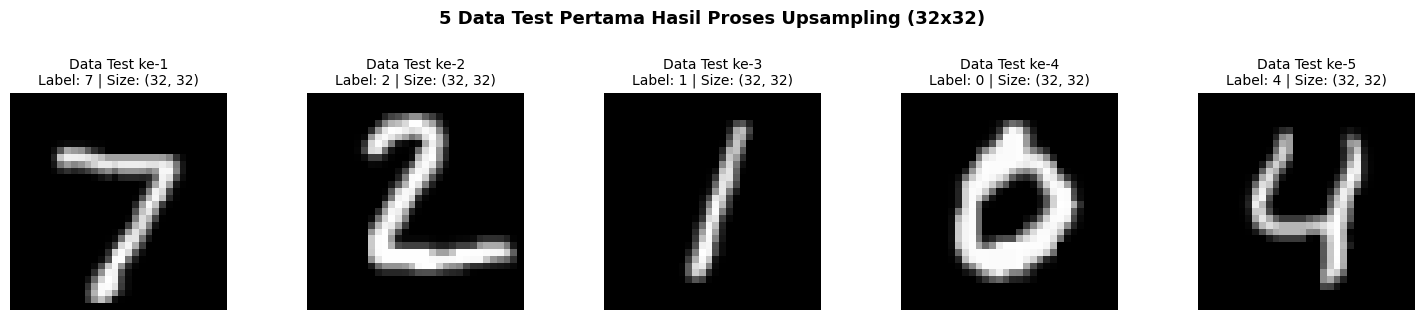

In [28]:
# Jawab Soal 1 - Upsampling Citra Menjadi Ukuran 32x32
import cv2
import numpy as np
import matplotlib.pyplot as plt

X_test_upsampled = np.zeros((X_test.shape[0], 32, 32), dtype=X_test.dtype)

def upsample_image(img, target_size=(32, 32)):
    return cv2.resize(img, target_size, interpolation=cv2.INTER_LINEAR)

for i in range(len(X_test)):
    X_test_upsampled[i] = upsample_image(X_test[i], target_size=(32, 32))

print("Ukuran X_test sebelum upsampling :", X_test.shape)
print("Ukuran X_test setelah upsampling :", X_test_upsampled.shape)
print("Tipe data array penampung        :", X_test_upsampled.dtype)

plt.figure(figsize=(15, 3))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(X_test_upsampled[i], cmap="gray")
    plt.title(f"Data Test ke-{i+1}\nLabel: {y_test[i]} | Size: {X_test_upsampled[i].shape}", fontsize=10)
    plt.axis("off")

plt.suptitle("5 Data Test Pertama Hasil Proses Upsampling (32x32)", fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


## Soal 2 (10 poin)
Lakukan normalisasi nilai citra tiap piksel menjadi rentang 0-1

In [29]:
# Jawab Soal 2 - Normalisasi Nilai Piksel Menjadi Rentang [0, 1]
import numpy as np

X_test_normalized = X_test_upsampled.astype(np.float32) / 255.0

print('HASIL NORMALISASI PIKSEL CITRA')
print('Ukuran dimensi array                      :', X_test_normalized.shape)
print('Tipe data setelah normalisasi             :', X_test_normalized.dtype)
print(f'Nilai piksel minimum (Min)                : {X_test_normalized.min():.4f}')
print(f'Nilai piksel maksimum (Max)                : {X_test_normalized.max():.4f}')
print(f'Nilai piksel rata-rata (Mean)             : {X_test_normalized.mean():.4f}')
print('=' * 50)

print('Cuplikan nilai piksel (6x6 bagian tengah data test pertama):')
print(np.round(X_test_normalized[0, 13:19, 13:19], 3))


HASIL NORMALISASI PIKSEL CITRA
Ukuran dimensi array                      : (10000, 32, 32)
Tipe data setelah normalisasi             : float32
Nilai piksel minimum (Min)                : 0.0000
Nilai piksel maksimum (Max)                : 1.0000
Nilai piksel rata-rata (Mean)             : 0.1326
Cuplikan nilai piksel (6x6 bagian tengah data test pertama):
[[0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.012]
 [0.    0.    0.    0.    0.    0.149]
 [0.    0.    0.    0.    0.    0.322]
 [0.    0.    0.    0.    0.02  0.498]]


## Soal 3 (10 poin)
Ubah metriks citra menjadi array 1 dimensi. Lakukan pada semua data test yang sudah di resize dan normalisasi.

Hint: Anda harus membuat holder array kosong untuk menampung hasilnya.

In [30]:
# Jawab Soal 3 - Mengubah Matriks Citra Menjadi Array 1 Dimensi
import numpy as np

n_samples = X_test_normalized.shape[0]
n_features = X_test_normalized.shape[1] * X_test_normalized.shape[2]  

X_test_flattened = np.zeros((n_samples, n_features), dtype=np.float32)

for i in range(n_samples):
    X_test_flattened[i] = X_test_normalized[i].flatten()

print('=== HASIL TRANSFORMASI MATRIKS CITRA KE ARRAY 1D ===')
print('Dimensi data sebelum diubah (matriks 2D) : ', X_test_normalized.shape)
print('Dimensi data setelah diubah (array 1D)   : ', X_test_flattened.shape)
print('Jumlah fitur piksel per sampel citra     : ', X_test_flattened.shape[1])
print('Tipe data array                          : ', X_test_flattened.dtype)
print('=' * 55)

print(f'Bentuk dimensi data test ke-1           : {X_test_flattened[0].shape} (1 Dimensi)')
print('Cuplikan 10 nilai fitur piksel pertama pada citra ke-1:')
print(np.round(X_test_flattened[0, :10], 4))


=== HASIL TRANSFORMASI MATRIKS CITRA KE ARRAY 1D ===
Dimensi data sebelum diubah (matriks 2D) :  (10000, 32, 32)
Dimensi data setelah diubah (array 1D)   :  (10000, 1024)
Jumlah fitur piksel per sampel citra     :  1024
Tipe data array                          :  float32
Bentuk dimensi data test ke-1           : (1024,) (1 Dimensi)
Cuplikan 10 nilai fitur piksel pertama pada citra ke-1:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
